In [187]:
from datasets import load_from_disk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [188]:
likes = load_from_disk('dataset-parts/yambda_likes')
dislikes = load_from_disk('dataset-parts/yambda_dislikes')
listens = load_from_disk('dataset-parts/yambda_listens')

likes_table = likes.data.table
dislikes_table = dislikes.data.table
listens_table = listens.data.table


likes_df: pd.DataFrame = pd.DataFrame.from_arrow(likes_table)
# dislikes_df: pd.DataFrame = pd.DataFrame.from_arrow(dislikes_table)
listens_df: pd.DataFrame = pd.DataFrame.from_arrow(listens_table)

likes_df['event_type'] = 'like'
# dislikes_df['event_type'] = 'dislike'
listens_df['event_type'] = 'listen'

yambda_df = pd.concat([likes_df, listens_df], ignore_index=True)

# yambda_df = pd.concat([likes_df, dislikes_df, listens_df], ignore_index=True)
# yambda_df = pd.concat([likes_df, dislikes_df], ignore_index=True)

yambda_df = yambda_df.sort_values('timestamp')

yambda_df

,uid,timestamp,item_id,is_organic,event_type,played_ratio_pct,track_length_seconds
22879986,468300,0,7400764,0,listen,100.0,225.0
17033976,347600,5,3415205,0,listen,100.0,250.0
44773176,942900,10,6728180,0,listen,1.0,270.0
1388942,12700,15,8932363,0,listen,100.0,245.0
12164540,243500,15,5283544,1,listen,100.0,195.0
...,...,...,...,...,...,...,...
30815427,645300,25999995,1172812,1,listen,100.0,120.0
9620970,190700,25999995,875069,0,listen,0.0,235.0
7523389,144700,26000000,6281650,0,listen,6.0,205.0
42998457,903600,26000000,8370890,1,listen,6.0,220.0


In [189]:
yambda_df_organic = yambda_df[yambda_df['is_organic'] == 1].drop(['is_organic'], axis=1)

yambda_df_organic

,uid,timestamp,item_id,event_type,played_ratio_pct,track_length_seconds
12164540,243500,15,5283544,listen,100.0,195.0
21477859,438800,20,5638983,listen,43.0,145.0
37768322,789000,25,3001214,listen,100.0,210.0
21477860,438800,25,8234039,listen,4.0,180.0
18074153,368100,30,1973887,listen,100.0,235.0
...,...,...,...,...,...,...
42851736,899900,25999995,3982725,listen,100.0,240.0
42851737,899900,25999995,4027449,listen,100.0,240.0
26737229,554500,25999995,1011428,listen,3.0,115.0
30815427,645300,25999995,1172812,listen,100.0,120.0


In [190]:
weak_ticks = (7 * 24 * 3600) // 5
year_ticks = (365 * 24 * 3600) // 5

weak_ticks, year_ticks

(120960, 6307200)

In [191]:
max_time = yambda_df_organic['timestamp'].max()

test_start = max_time - weak_ticks
train_start = test_start - year_ticks

In [192]:
train_df = yambda_df_organic[
    (yambda_df_organic['timestamp'] >= train_start) &
    (yambda_df_organic['timestamp'] < test_start)
]

test_df = yambda_df_organic[yambda_df_organic['timestamp'] >= test_start]

Количество уникальных айтемов и пользователей

In [193]:
train_df['item_id'].nunique(), train_df['uid'].nunique()

(395459, 9422)

In [194]:
users_activity = train_df['uid'].value_counts()

In [195]:
users_activity.describe()

count     9422.000000
mean       820.888240
std       1124.188043
min          1.000000
25%         99.000000
50%        414.000000
75%       1080.750000
max      11802.000000
Name: count, dtype: float64

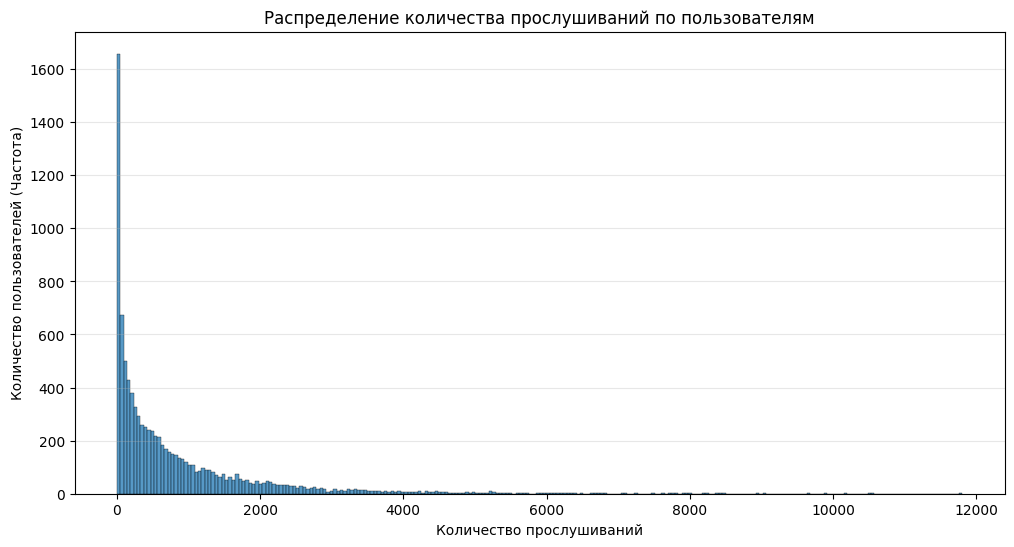

In [196]:
plt.figure(figsize=(12, 6))

sns.histplot(users_activity, bins=250)

plt.title('Распределение количества прослушиваний по пользователям')
plt.xlabel('Количество прослушиваний')
plt.ylabel('Количество пользователей (Частота)')
plt.grid(axis='y', alpha=0.3)
plt.show()

<Axes: xlabel='count'>

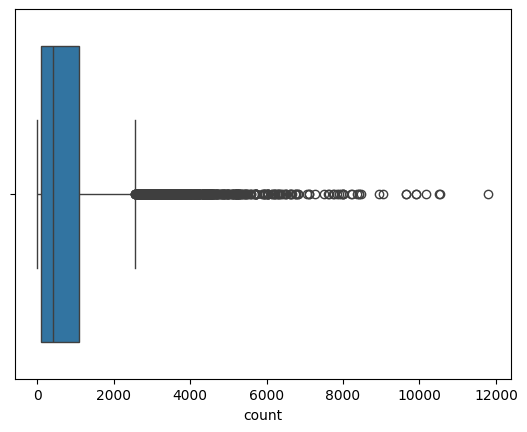

In [197]:
sns.boxplot(x=users_activity)

In [198]:
quantiles = [0.25, 0.5, 0.75, 0.8, 0.9, 0.95, 0.99, 0.999]

for quantile in quantiles:
    print(f'Listens quntile {quantile * 100}%: {users_activity.quantile(quantile)}')

Listens quntile 25.0%: 99.0
Listens quntile 50.0%: 414.0
Listens quntile 75.0%: 1080.75
Listens quntile 80.0%: 1332.8000000000002
Listens quntile 90.0%: 2152.7999999999993
Listens quntile 95.0%: 3043.7999999999956
Listens quntile 99.0%: 5267.269999999988
Listens quntile 99.9%: 8739.603999999868


In [199]:

groups = pd.qcut(users_activity, q=[0, 0.3, 0.6, 0.9, 0.95, 1.0], duplicates='drop')

counts = groups.value_counts().sort_index()

print('Users activity distribution')
print(counts)

Users activity distribution
count
(0.999, 142.0]       2829
(142.0, 609.6]       2824
(609.6, 2152.8]      2826
(2152.8, 3043.8]      471
(3043.8, 11802.0]     472
Name: count, dtype: int64


Думаю, что можно взять пользователей между 30 и 90 кватилями  

In [200]:
low_threshold = users_activity.quantile(0.35)
high_threshold = users_activity.quantile(0.9)

active_user_ids = users_activity[
    (users_activity >= low_threshold) & 
    (users_activity <= high_threshold)
].index

df_train_active = train_df[train_df['uid'].isin(active_user_ids)].reset_index(drop=True)

In [201]:
df_train_active['uid'].value_counts().describe()

count    5181.000000
mean      815.147848
std       511.608978
min       196.000000
25%       394.000000
50%       671.000000
75%      1151.000000
max      2151.000000
Name: count, dtype: float64

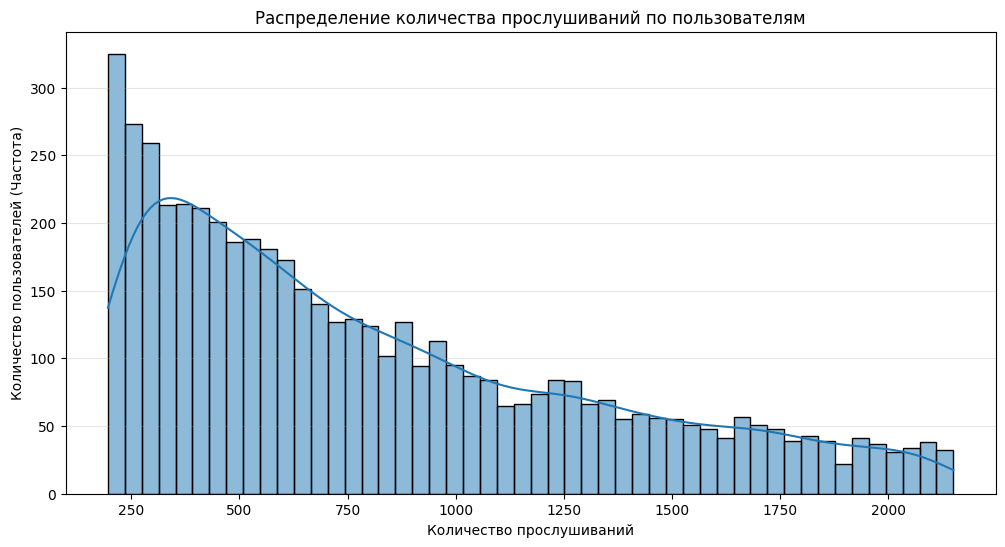

In [202]:
plt.figure(figsize=(12, 6))

sns.histplot(df_train_active['uid'].value_counts(), kde=True, bins=50)

plt.title('Распределение количества прослушиваний по пользователям')
plt.xlabel('Количество прослушиваний')
plt.ylabel('Количество пользователей (Частота)')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [203]:
df_train_active

,uid,timestamp,item_id,event_type,played_ratio_pct,track_length_seconds
0,912700,19571840,4270521,listen,50.0,340.0
1,912700,19571840,4058423,listen,100.0,235.0
2,912700,19571840,134761,listen,100.0,130.0
3,912700,19571840,7027100,listen,100.0,250.0
4,912700,19571840,1006437,listen,101.0,150.0
...,...,...,...,...,...,...
4223276,227300,25879030,4515938,listen,100.0,190.0
4223277,876800,25879030,5541036,listen,31.0,210.0
4223278,994700,25879035,5129354,listen,100.0,135.0
4223279,494500,25879035,558039,listen,63.0,175.0


In [204]:
df_train_active.item_id.nunique(), df_train_active.uid.nunique()

(306852, 5181)

Сейчас у нас есть следующие формы взаимодействия:
* Лайк
* Дизлайк
* Прослушивание

Сформируем весовую матрицу взаиомодействий:

* Лайк: 1.0
* Дизлайк: 0.01
* Прослушивание: `min(max((mean(track.played_ratio_pct / 100)), 1.0), 0.1)`, т.е получится диапазон от 0.1 до 1.0


In [205]:
df_train_active.event_type.value_counts()

event_type
listen    4141095
like        82186
Name: count, dtype: int64

In [206]:
train_df[train_df[['played_ratio_pct']].isna().any(axis=1)]['event_type'].value_counts()

event_type
like    171020
Name: count, dtype: int64

In [207]:
train_df_sorted = train_df.sort_values(by=['uid', 'item_id', 'timestamp'])

explicit_df = train_df_sorted[train_df_sorted['event_type'] == 'like']
implicit_df = train_df_sorted[train_df_sorted['event_type'] == 'listen']

last_explicit = explicit_df.drop_duplicates(subset=['uid', 'item_id'], keep='last').copy()
last_explicit['interaction_weighted'] = 1.0
last_explicit = last_explicit[['uid', 'item_id', 'interaction_weighted']].reset_index(drop=True)

LISTEN_PLAYED_RATIO_THRESHOLD = 0.85
listen_mean_ratio = implicit_df.groupby(['uid', 'item_id'], as_index=False)['played_ratio_pct'].mean()
listen_mean_ratio['interaction_weighted'] = (
    listen_mean_ratio['played_ratio_pct'].fillna(-1) / 100.0 >= LISTEN_PLAYED_RATIO_THRESHOLD
).astype(float)
listen_agg = listen_mean_ratio[['uid', 'item_id', 'interaction_weighted']]

explicit_part = last_explicit.rename(columns={"interaction_weighted": "w_explicit"})
implicit_part = listen_agg.rename(columns={"interaction_weighted": "w_implicit"})

user_item_weighted = explicit_part.merge(
    implicit_part,
    on=["uid", "item_id"],
    how="outer",
)

user_item_weighted["interaction_weighted"] = user_item_weighted["w_explicit"].combine_first(
    user_item_weighted["w_implicit"]
)

user_item_weighted = user_item_weighted[["uid", "item_id", "interaction_weighted"]]

In [208]:
user_item_weighted

,uid,item_id,interaction_weighted
0,100,88111,1.0
1,100,152884,1.0
2,100,155792,1.0
3,100,225669,1.0
4,100,286361,1.0
...,...,...,...
2488692,1000000,8323008,1.0
2488693,1000000,8374442,0.0
2488694,1000000,8732545,0.0
2488695,1000000,8750380,1.0


In [209]:
train_users_weighted = set(user_item_weighted['uid'])
train_items_weighted = set(user_item_weighted['item_id'])

test_clean = test_df[
    test_df['uid'].isin(train_users_weighted) &
    test_df['item_id'].isin(train_items_weighted)
]

In [210]:
item2id = {k: v for v, k in enumerate(user_item_weighted['item_id'].unique())}
user2id = {k: v for v, k in enumerate(user_item_weighted['uid'].unique())}

id2item = {v: k for k, v in item2id.items()}
id2user = {v: k for k, v in user2id.items()}

In [211]:
user_item_weighted['uidx'] = user_item_weighted['uid'].map(user2id)
user_item_weighted['item_idx'] = user_item_weighted['item_id'].map(item2id)

In [212]:
user_item_weighted

,uid,item_id,interaction_weighted,uidx,item_idx
0,100,88111,1.0,0,0
1,100,152884,1.0,0,1
2,100,155792,1.0,0,2
3,100,225669,1.0,0,3
4,100,286361,1.0,0,4
...,...,...,...,...,...
2488692,1000000,8323008,1.0,9421,52957
2488693,1000000,8374442,0.0,9421,3480
2488694,1000000,8732545,0.0,9421,3513
2488695,1000000,8750380,1.0,9421,11896


In [213]:
user_item_weighted['uid'].nunique(), user_item_weighted['item_id'].nunique()

(9422, 395459)

In [214]:
from scipy.sparse import csr_matrix

user_item_weighted_sparse = csr_matrix(
    (
        user_item_weighted['interaction_weighted'],
        (user_item_weighted['uidx'], user_item_weighted['item_idx'])
    ),
    shape=(len(user2id), len(item2id))
)

Metrics import 

In [215]:
from metrics import (
    recall_at_k,
    precision_at_k,
    ndcg_at_k,
    map_at_k,
    hit_rate_at_k,
)

Истинные взаимодействия, пока без разделения на лайки/дизлайки

In [216]:
test_true = test_clean.groupby('uid')['item_id'].apply(set).to_dict()

In [230]:
test_clean.item_id.nunique()

48352

UserKNN

In [218]:
from models import UserKNN

In [219]:
userknn_weighted = UserKNN()
userknn_weighted.fit(user_item_weighted_sparse)

In [220]:
recall_userknn_weighted = recall_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    k=100,
    recommend_fn=userknn_weighted.predict
)
precision_userknn_weighted = precision_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    k=100,
    recommend_fn=userknn_weighted.predict
)
ndcg_userknn_weighted = ndcg_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    k=100,
    recommend_fn=userknn_weighted.predict
)
map_userknn_weighted = map_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    k=100,
    recommend_fn=userknn_weighted.predict
)
hit_rate_userknn_weighted = hit_rate_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    k=100,
    recommend_fn=userknn_weighted.predict
)

print('UserKNN weighted NDCG@100:', ndcg_userknn_weighted)
print('UserKNN weighted Recall@100:', recall_userknn_weighted)
# print('UserKNN weighted Precision@100:', precision_userknn_weighted)
print('UserKNN weighted MAP@100:', map_userknn_weighted)
print('UserKNN weighted HitRate@100:', hit_rate_userknn_weighted)


UserKNN weighted NDCG@100: 0.030950332769813786
UserKNN weighted Recall@100: 0.041474030195766814
UserKNN weighted MAP@100: 0.00793350068432256
UserKNN weighted HitRate@100: 0.35046728971962615


ItemKNN

In [ ]:
from models import ItemKNN

In [ ]:
itemknn_weighted = ItemKNN()
itemknn_weighted.fit(user_item_weighted_sparse)

: 

In [ ]:
recall_itemknn_weighted = recall_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)
precision_itemknn_weighted = precision_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)
ndcg_itemknn_weighted = ndcg_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)
map_itemknn_weighted = map_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)
hit_rate_itemknn_weighted = hit_rate_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)

print('ItemKNN weighted NDCG@10:', ndcg_itemknn_weighted)
print('ItemKNN weighted Recall@10:', recall_itemknn_weighted)
# print('ItemKNN weighted Precision@10:', precision_itemknn_weighted)
print('ItemKNN weighted MAP@10:', map_itemknn_weighted)
print('ItemKNN weighted HitRate@10:', hit_rate_itemknn_weighted)


NameError: name 'itemknn_weighted' is not defined

ELSA


In [221]:
from models import ELSA

In [222]:
elsa_weighted = ELSA()
elsa_weighted.fit(user_item_weighted_sparse)


In [223]:
recall_elsa_weighted = recall_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    k=100,
    recommend_fn=elsa_weighted.predict,
)
precision_elsa_weighted = precision_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    k=100,
    recommend_fn=elsa_weighted.predict,
)
ndcg_elsa_weighted = ndcg_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    k=100,
    recommend_fn=elsa_weighted.predict,
)
map_elsa_weighted = map_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    k=100,
    recommend_fn=elsa_weighted.predict,
)
hit_rate_elsa_weighted = hit_rate_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    k=100,
    recommend_fn=elsa_weighted.predict,
)

print('ELSA weighted NDCG@100:', ndcg_elsa_weighted)
print('ELSA weighted Recall@100:', recall_elsa_weighted)
print('ELSA weighted Precision@100:', precision_elsa_weighted)
print('ELSA weighted MAP@100:', map_elsa_weighted)
print('ELSA weighted HitRate@100:', hit_rate_elsa_weighted)


ELSA weighted NDCG@100: 0.03687950303314651
ELSA weighted Recall@100: 0.05216535433070866
ELSA weighted Precision@100: 0.01285491766800178
ELSA weighted MAP@100: 0.008813475936695354
ELSA weighted HitRate@100: 0.4205607476635514


iALS


In [224]:
from models import iALS

In [225]:
ials_weighted = iALS()
ials_weighted.fit(user_item_weighted_sparse)

100%|██████████| 25/25 [00:15<00:00,  1.57it/s]


In [226]:
recall_ials_weighted = recall_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    k=100,
    recommend_fn=ials_weighted.predict,
)
precision_ials_weighted = precision_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    k=100,
    recommend_fn=ials_weighted.predict,
)
ndcg_ials_weighted = ndcg_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    k=100,
    recommend_fn=ials_weighted.predict,
)
map_ials_weighted = map_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    k=100,
    recommend_fn=ials_weighted.predict,
)
hit_rate_ials_weighted = hit_rate_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    k=100,
    recommend_fn=ials_weighted.predict,
)

print('iALS weighted NDCG@100:', ndcg_ials_weighted)
print('iALS weighted Recall@100:', recall_ials_weighted)
print('iALS weighted Precision@100:', precision_ials_weighted)
print('iALS weighted MAP@100:', map_ials_weighted)
print('iALS weighted HitRate@100:', hit_rate_ials_weighted)


iALS weighted NDCG@100: 0.01662267548425526
iALS weighted Recall@100: 0.02131040959329625
iALS weighted Precision@100: 0.0052514463729417
iALS weighted MAP@100: 0.00424081771010724
iALS weighted HitRate@100: 0.2076101468624833


TopPopular, TopPersonal, TopPersonal+TopPopular

In [227]:
from models import TopPopular, TopPersonal, TopPersonalTopPopular


top_popular_weighted = TopPopular()
top_popular_weighted.fit(user_item_weighted_sparse)


top_personal_weighted = TopPersonal()
top_personal_weighted.fit(user_item_weighted_sparse)


hybrid_weighted = TopPersonalTopPopular()
hybrid_weighted.fit(user_item_weighted_sparse)


In [228]:
def print_metrics_all(label, model, R, k=100):
    fn = model.predict
    print(f"=== {label} ===")
    print(f"Recall@{k}:", recall_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print(f"Precision@{k}:", precision_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print(f"NDCG@{k}:", ndcg_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print(f"MAP@{k}:", map_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print(f"HitRate@{k}:", hit_rate_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print()


for name, m, R in [
    ("TopPopular weighted", top_popular_weighted, user_item_weighted_sparse),
    ("TopPersonal weighted", top_personal_weighted, user_item_weighted_sparse),
    ("TopPersonal+TopPopular weighted", hybrid_weighted, user_item_weighted_sparse),
]:
    print_metrics_all(name, m, R)


=== TopPopular weighted ===
Recall@100: 0.029563678393411834
Precision@100: 0.007285269247886071
NDCG@100: 0.020859526911195903
MAP@100: 0.0048979833329234855
HitRate@100: 0.27814864263462397

=== TopPersonal weighted ===
Recall@100: 0.041474030195766814
Precision@100: 0.010220293724966622
NDCG@100: 0.030950332769813786
MAP@100: 0.00793350068432256
HitRate@100: 0.35046728971962615

=== TopPersonal+TopPopular weighted ===
Recall@100: 0.03418695369500831
Precision@100: 0.00842456608811749
NDCG@100: 0.027385392303612473
MAP@100: 0.007514809025630608
HitRate@100: 0.315086782376502

